In [5]:
import healpy as hp
import numpy as np
from scipy.special import sph_harm


nside = 32
npix = hp.nside2npix(nside)

# Get theta, phi for each pixel
theta, phi = hp.pix2ang(nside, np.arange(npix))

# Evaluate Y_lm at each pixel
l = 5
m = -3

Y_lm = sph_harm(m, l, phi, theta)   # shape (npix,)


In [6]:
print(Y_lm)

[-3.24765155e-05-3.24765155e-05j  3.24765155e-05-3.24765155e-05j
  3.24765155e-05+3.24765155e-05j ...  3.24765155e-05-3.24765155e-05j
  3.24765155e-05+3.24765155e-05j -3.24765155e-05+3.24765155e-05j]


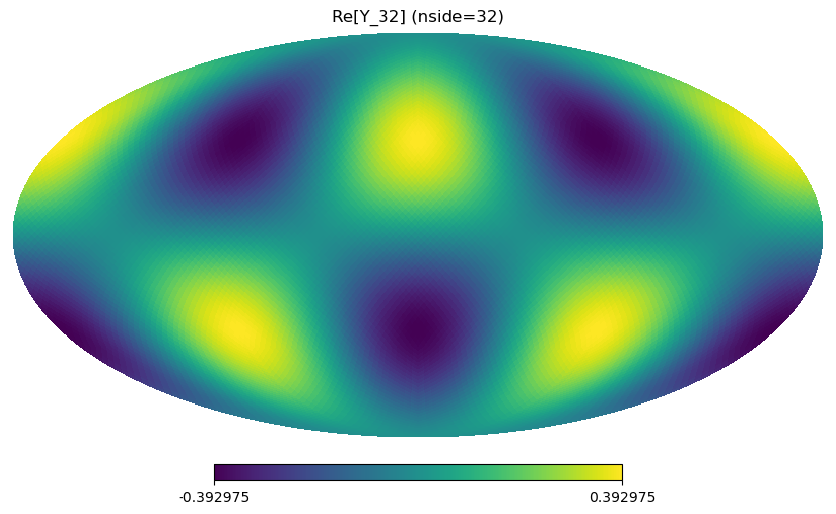

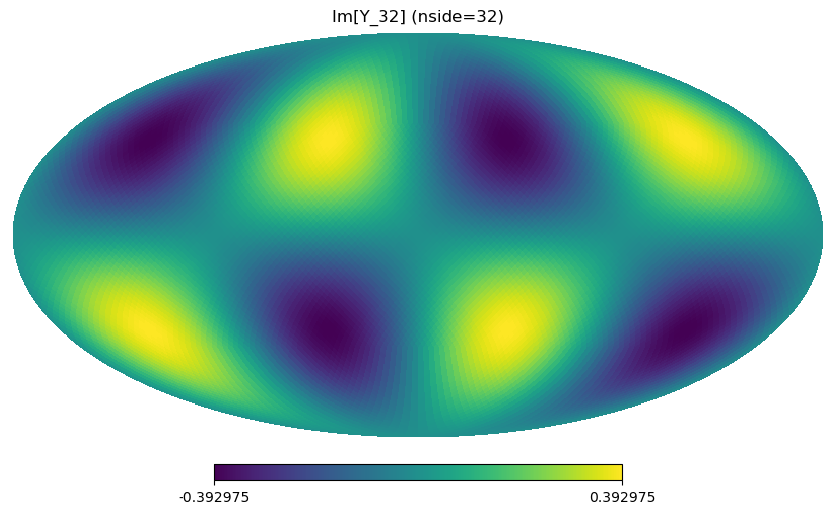

In [7]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.special import sph_harm

# Choose HEALPix resolution and (l, m)
nside = 32
l, m = 3, 2

npix = hp.nside2npix(nside)

# Get theta, phi for every pixel
theta, phi = hp.pix2ang(nside, np.arange(npix))  # theta in [0, pi], phi in [0, 2pi)

# Evaluate complex spherical harmonic Y_lm on each pixel
Y_lm = sph_harm(m, l, phi, theta)  # shape (npix,)

# You can plot real or imaginary part; HEALPix maps are real-valued
map_real = Y_lm.real
map_imag = Y_lm.imag

# Plot real part in a Mollweide projection
hp.mollview(map_real, title=f"Re[Y_{l}{m}] (nside={nside})", unit="")
plt.show()

# Plot imaginary part if you want
hp.mollview(map_imag, title=f"Im[Y_{l}{m}] (nside={nside})", unit="")
plt.show()


(24, 47)


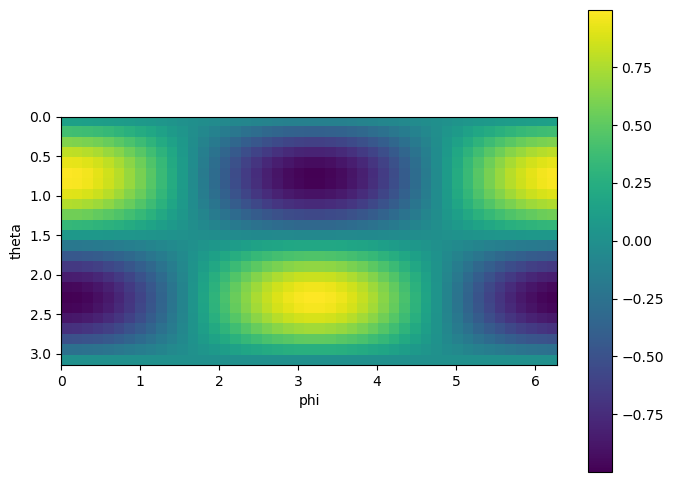

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


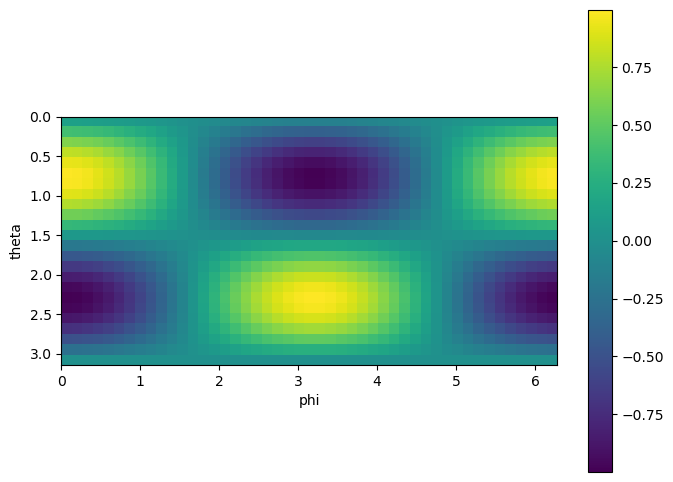

Mean absolute error = 7.104887913556013e-07


In [8]:
import s2fft
import numpy as np
import matplotlib.pyplot as plt

# Define sampled signal to transform and harmonic bandlimit

n_theta = 24
n_phi = 47
L = 24

i = np.arange(n_theta)

theta = (np.pi * (2*i+1))/ (2*L - 1)

j = np.arange(n_phi)

phi = (2 * np.pi * j) / (2*L - 1)



func_tp = []

for i in theta:
    f_phi = []
    for j in phi:
        f_phi.append(np.sin(2*i) * np.cos(j))
    func_tp.append(f_phi)

func_tp = np.array(func_tp)
print(func_tp.shape)

plt.figure(figsize=(8, 6))
plt.imshow(func_tp, extent=(0, 2 * np.pi, np.pi, 0))
plt.xlabel('phi')
plt.ylabel('theta')
plt.colorbar()
plt.show()

L = 24
# Compute harmonic coefficients
flm = s2fft.forward(func_tp, L, sampling="mw", method = 'jax')

# Map back to pixel-space signal
f_recov = s2fft.inverse(flm, L, sampling="mw", method = 'jax')

plt.figure(figsize=(8, 6))

plt.imshow(f_recov.real, extent=(0, 2 * np.pi, np.pi, 0))
plt.xlabel('phi')
plt.ylabel('theta')
plt.colorbar()
plt.show()

print(f"Mean absolute error = {np.nanmean(np.abs(f_recov - func_tp))}")